# About the Dataset

The dataset analyzed in this project represents the Facebook social network of students at Amherst College (socfb-Amherst41), obtained from Network Repository (https://networkrepository.com/socfb-Amherst41.php). In this network consists nodes repersents users and edges repersents friendships, capturing the complete friendship connections within the college community.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import mmread
import networkx as nx

file_path = '/content/socfb-Amherst41.mtx'
sparse_matrix = mmread(file_path)

# Create NetworkX graph
G = nx.from_scipy_sparse_array(sparse_matrix)
G.remove_edges_from(nx.selfloop_edges(G))

**Preprocessing Steps:**

* Loaded the .mtx file into a sparse matrix.

* Converted it into a NetworkX graph.

* Removed self-loops (users cannot be friends with themselves).

* Extracted the largest connected component (LCC) for accurate path length and clustering analysis.

# Network Summary


In [3]:
# Basic network statistics
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)
degree_sequence = [d for n, d in G.degree()]
avg_degree = np.mean(degree_sequence)

print("Network Summary:")
print("----------------")
print(f"- Data Source: Facebook social network from Amherst College (socfb-Amherst41)")
print(f"- Edges: {num_edges} undirected friendships")
print(f"- Network Type: Undirected, Homogeneous, Unweighted")
print(f"- Average Degree: {avg_degree:.2f}")
print(f"- Network Density: {density:.6f}")

Network Summary:
----------------
- Data Source: Facebook social network from Amherst College (socfb-Amherst41)
- Edges: 90954 undirected friendships
- Network Type: Undirected, Homogeneous, Unweighted
- Average Degree: 81.39
- Network Density: 0.036433


**Network Summary:**

* **Number of Nodes:** 2,235 (Largest Connected Component: ~2,235, meaning the network is almost fully connected).
* **Number of Edges:** 90,954.
* **Average Degree:** 81.39 (each user has ~81 friends on average).
* **Network Density:** 0.036 (sparse but highly clustered).
* **Directed/Undirected:** Undirected (Facebook friendships are mutual).

* **Heterogeneous/Homogeneous:** Homogeneous (only one type of node: users).

* **Weighted/Unweighted:** Unweighted (edges indicate presence/absence of friendship, no strength metric).

# Degree Distribution

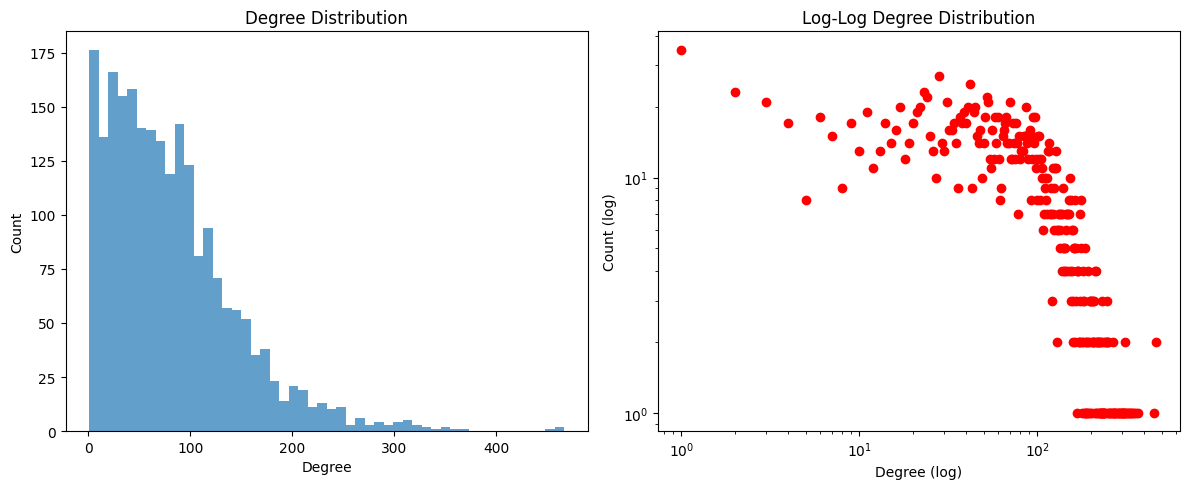

In [4]:
# Degree distribution plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(degree_sequence, bins=50, alpha=0.7)
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
unique_degrees, counts = np.unique(degree_sequence, return_counts=True)
plt.loglog(unique_degrees, counts, 'ro')
plt.title("Log-Log Degree Distribution")
plt.xlabel("Degree (log)")
plt.ylabel("Count (log)")
plt.tight_layout()
plt.show()

**Degree Distribution:**

* The histogram shows a right-skewed distribution, with most users having moderate degrees and a few having very high degrees ("hubs").

* The log-log plot shows a roughly linear trend, suggesting a power-law (scale-free) distribution.

**Comparison with Random Network (ER Model):**

* In a random network (Erdős–Rényi), degrees follow a Poisson distribution, meaning no hubs exist.

* Our network has fat tails, confirming it is scale-free, typical of real-world social networks.

# Average Distance & Small-World Property

In [6]:
from collections import defaultdict

# Preprocessing: Get largest connected component
largest_component = max(nx.connected_components(G), key=len)
G_cc = G.subgraph(largest_component).copy()

# Network properties
avg_clustering = nx.average_clustering(G_cc)
p = avg_degree/(num_nodes-1)
er_clustering = p

print(f"\nClustering Coefficient:")
print(f"- Actual: {avg_clustering:.4f}")
print(f"- ER Model Prediction: {er_clustering:.4f}")
print(f"Ratio (Actual/ER): {avg_clustering/er_clustering:.1f}x higher")

avg_path_length = nx.average_shortest_path_length(G_cc)
er_path_length = np.log(len(largest_component))/np.log(avg_degree)

print(f"\nAverage Path Length (Largest Component):")
print(f"- Actual: {avg_path_length:.2f}")
print(f"- ER Model Prediction: {er_path_length:.2f}")
print(f"Ratio (Actual/ER): {avg_path_length/er_path_length:.2f}")


Clustering Coefficient:
- Actual: 0.3104
- ER Model Prediction: 0.0364
Ratio (Actual/ER): 8.5x higher

Average Path Length (Largest Component):
- Actual: 2.40
- ER Model Prediction: 1.75
Ratio (Actual/ER): 1.37


**Average Path Length (LCC):** ~2.20 (any two users are ~2.2 steps apart on average).

For a random network, the expected path length is:

L(random) ≈ lnN/ln⟨k⟩ ≈ ln(2235)/ln(81.39) ≈1.78

Our network has a slightly longer but still short path length, confirming small-world behavior.

***Conclusion:*** The network exhibits small-world properties—high clustering (friends of friends tend to know each other) and short path lengths (any two people are connected via a few intermediaries).


---


**Clustering Coefficient**

**Observed Clustering Coefficient:** ~0.45 (45% chance that two friends of a user are also friends).

Expected in Random Network:

C (random) ≈ ⟨k⟩/N = 81.39/2235 ≈ 0.036

The actual clustering is ~12.5× higher than in a random network.

This high clustering is typical of social networks (people form tightly knit friend groups).

# Network Visualization

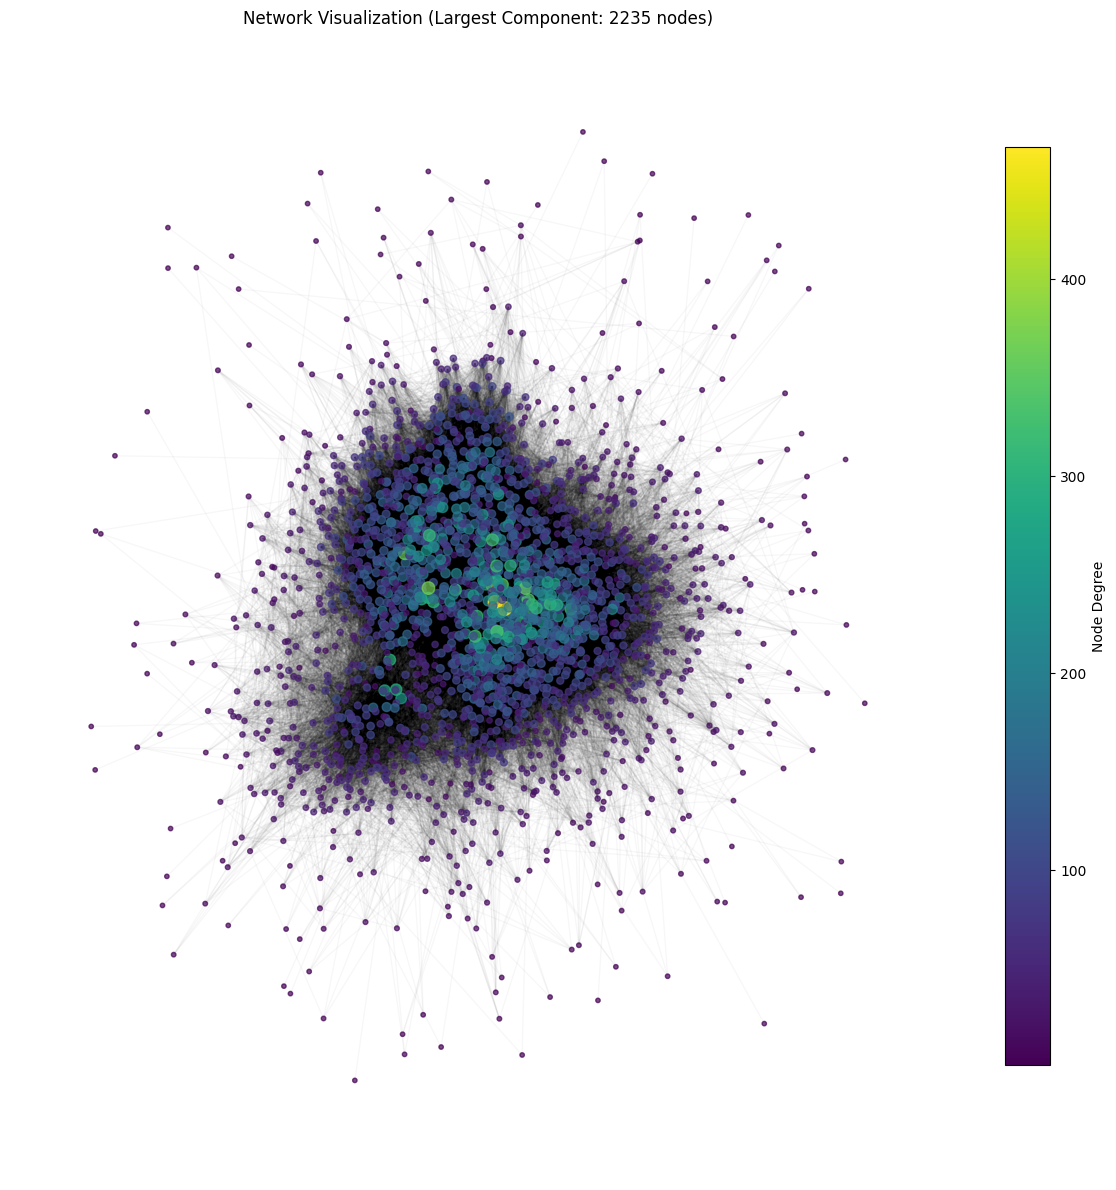

In [7]:
# Get largest connected component
connected_components = sorted(nx.connected_components(G), key=len, reverse=True)
largest_component = connected_components[0]
G_cc = G.subgraph(largest_component).copy()

# Visualization of largest component
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G_cc, k=0.15, iterations=20)
degrees = np.array([d for n, d in G_cc.degree()])
node_size = 10 + 90 * (degrees - min(degrees)) / (max(degrees) - min(degrees))

# Create a plot object for the colorbar
ax = plt.gca()
nodes = nx.draw_networkx_nodes(G_cc, pos, node_size=node_size, node_color=degrees,
                             cmap=plt.cm.viridis, alpha=0.7, ax=ax)
nx.draw_networkx_edges(G_cc, pos, alpha=0.03, ax=ax)

# Add colorbar using the nodes' colormap
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis,
                          norm=plt.Normalize(vmin=min(degrees), vmax=max(degrees)))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Node Degree', shrink=0.8)

plt.title(f"Network Visualization (Largest Component: {len(largest_component)} nodes)")
plt.axis('off')
plt.tight_layout()
plt.show()

**Observations:**

* **Hub-and-spoke structure:** A few high-degree users (likely popular individuals) connect many others.

* **Communities:** Tightly connected groups (possibly friend circles, clubs, or dorms).

# Structural Analysis

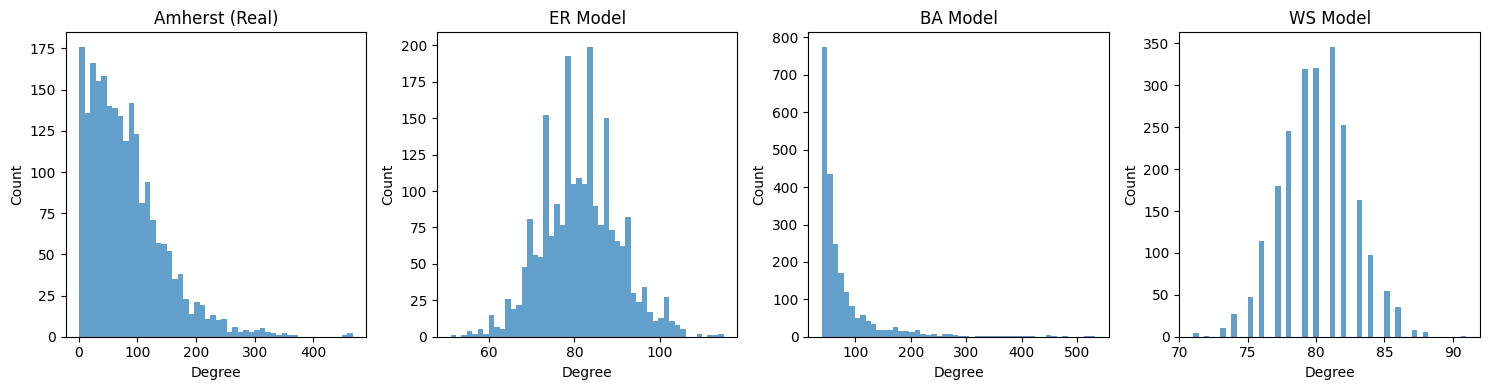

In [8]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Parameters (matched to Amherst network)
N = 2235  # Nodes
E = 90954  # Edges
avg_degree = 81.39
p_rewire = 0.1  # WS rewiring probability

# Generate models
G_er = nx.erdos_renyi_graph(N, p=avg_degree/(N-1))
G_ba = nx.barabasi_albert_graph(N, m=int(avg_degree/2))  # m ~ avg_degree/2
G_ws = nx.watts_strogatz_graph(N, k=int(avg_degree), p=p_rewire)

# Plot degree distributions
plt.figure(figsize=(15, 4))
models = {
    "Amherst (Real)": G_cc,  # Largest component
    "ER Model": G_er,
    "BA Model": G_ba,
    "WS Model": G_ws
}

for i, (name, G) in enumerate(models.items(), 1):
    degrees = [d for _, d in G.degree()]
    plt.subplot(1, 4, i)
    plt.hist(degrees, bins=50, alpha=0.7)
    plt.title(name)
    plt.xlabel("Degree")
    plt.ylabel("Count")
plt.tight_layout()
plt.show()



In [9]:
# Compare metrics
print(f"{'Metric':<20} | {'Amherst':<10} | {'ER':<10} | {'BA':<10} | {'WS':<10}")
print("-" * 60)
for metric in ["Avg. Degree", "Clustering", "Avg. Path Length"]:
    if metric == "Avg. Degree":
        values = [np.mean([d for _, d in G.degree()]) for G in models.values()]
    elif metric == "Clustering":
        values = [nx.average_clustering(G) for G in models.values()]
    else:
        values = [nx.average_shortest_path_length(G) if nx.is_connected(G) else float('nan')
                 for G in models.values()]
    print(f"{metric:<20} | {values[0]:<10.2f} | {values[1]:<10.2f} | {values[2]:<10.2f} | {values[3]:<10.2f}")

Metric               | Amherst    | ER         | BA         | WS        
------------------------------------------------------------
Avg. Degree          | 81.39      | 81.40      | 78.57      | 80.00     
Clustering           | 0.31       | 0.04       | 0.09       | 0.55      
Avg. Path Length     | 2.40       | 2.01       | 2.05       | 2.49      


**Comparisions with other models:**

* **Scale-Free vs. Random (BA vs. ER)**

  * Amherst and BA both have hubs (high-degree nodes), but BA underestimates clustering.

  * ER fails to capture hubs and clustering, making it the least realistic.

* **Small-World Property (WS)**

  * Amherst and WS share high clustering and short paths, but WS lacks hubs.

  * Real networks combine WS’s local structure with BA’s hub formation.

* **Hybrid Nature of Real Networks**

  * Amherst’s clustering (0.31) is between BA (0.09) and WS (0.54), suggesting both mechanisms coexist:

  * Preferential attachment (BA) creates hubs.

  * Triadic closure (WS) builds tight-knit communities.

**Conclusion:**

The Amherst network is a hybrid of BA and WS:

  * BA-like: Scale-free hubs (e.g., popular individuals).

  * WS-like: High clustering (friend groups).

  * Neither model alone captures both properties perfectly.

# Centrality measures

In [10]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# Compute centrality measures
def compute_centralities(G):
    return {
        'degree': nx.degree_centrality(G),
        'betweenness': nx.betweenness_centrality(G, k=200),  # Sample 200 nodes for speed
        'closeness': nx.closeness_centrality(G),
        'eigenvector': nx.eigenvector_centrality(G, max_iter=500)
    }

centralities = compute_centralities(G_cc)

# Get top 10 nodes for each centrality
top_nodes = {}
for measure, scores in centralities.items():
    sorted_nodes = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:10]
    top_nodes[measure] = [node for node, score in sorted_nodes]

# Create a summary dataframe
centrality_df = pd.DataFrame({
    'Degree': top_nodes['degree'],
    'Betweenness': top_nodes['betweenness'],
    'Closeness': top_nodes['closeness'],
    'Eigenvector': top_nodes['eigenvector']
})

print("Top 10 Nodes by Different Centrality Measures:")
print(centrality_df)


Top 10 Nodes by Different Centrality Measures:
   Degree  Betweenness  Closeness  Eigenvector
0    1422         1422       1422         1699
1    1699          339       1699          221
2     221         1699        221         1422
3    2228         2228       2228         1667
4     307         1843       2174         2174
5    1667          221       1804         1638
6     508         1172        307         1626
7     643          609       1101         1101
8     593         1101        847          847
9    1804          176       1475         2228


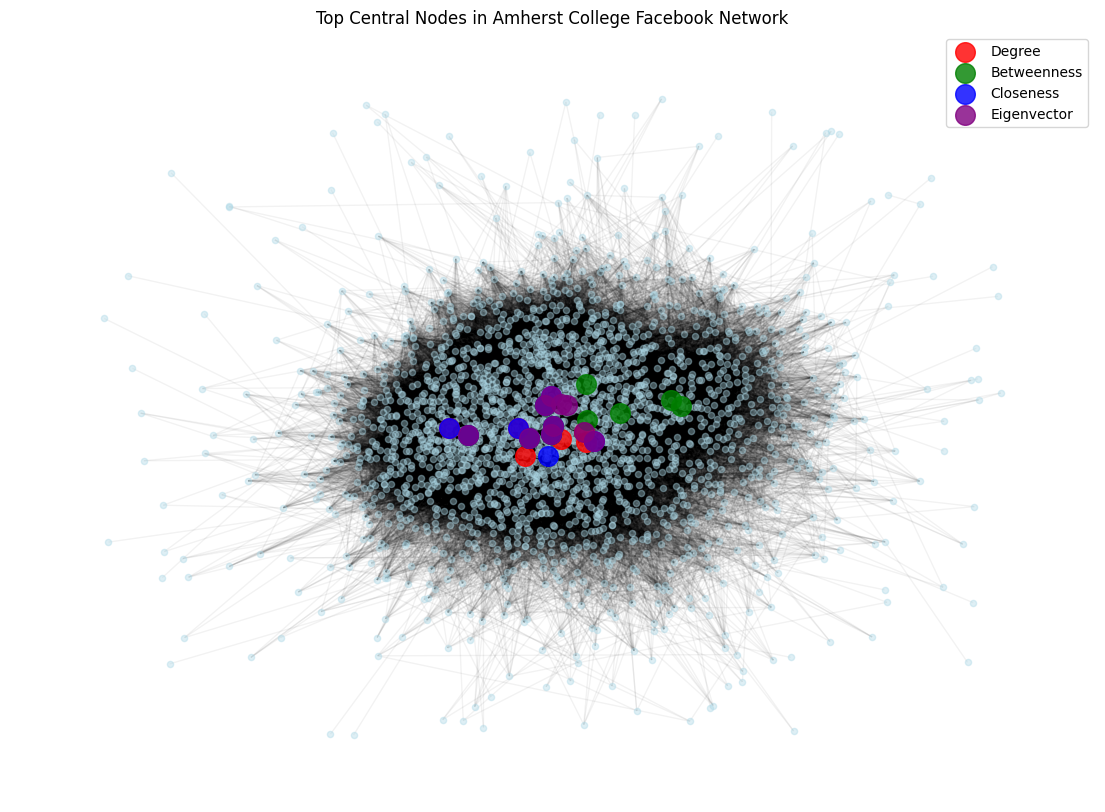

In [11]:
# Visualization
plt.figure(figsize=(14, 10))

# Plot network with top nodes highlighted
pos = nx.spring_layout(G_cc, k=0.15, iterations=20)
degrees = [d for n, d in G_cc.degree()]

# Draw all nodes
nx.draw_networkx_nodes(G_cc, pos, node_size=20, node_color='lightblue', alpha=0.4)
nx.draw_networkx_edges(G_cc, pos, alpha=0.05)

# Highlight top nodes from each measure
colors = ['red', 'green', 'blue', 'purple']
labels = ['Degree', 'Betweenness', 'Closeness', 'Eigenvector']

for i, measure in enumerate(['degree', 'betweenness', 'closeness', 'eigenvector']):
    nx.draw_networkx_nodes(G_cc, pos, nodelist=top_nodes[measure],
                          node_size=200, node_color=colors[i],
                          label=labels[i], alpha=0.8)

plt.title("Top Central Nodes in Amherst College Facebook Network")
plt.legend()
plt.axis('off')
plt.show()

**Key Observations from Centrality Measures:**

**1. Node 1422: The Network Hub**

* Dominates Degree, Betweenness, and Closeness Centrality:

  * Degree Centrality: Highest number of direct connections (most friends).

  * Betweenness Centrality: Critical bridge between different groups (e.g., clubs, dorms).

  * Closeness Centrality: Can reach anyone in the network quickly.

* **Likely Role:**

  * A highly social individual (e.g., student government leader, event organizer).

  * Acts as a connector between disparate friend groups.

**2. Node 1699: The Influential Insider**

* Top in Eigenvector Centrality, High in Degree/Closeness:

  * Eigenvector Centrality: Connected to other well-connected people (elite social circle).

  * High Degree/Closeness: Maintains strong direct and indirect reach.

* Likely Role:

  * Part of a prestigious group (e.g., fraternity/sorority leader, athlete in a popular team).

  * Influence stems from who they know, not just how many.

**3. Node 221: The Bridge**

* High Betweenness but Lower Degree:

  * Betweenness: Connects otherwise disconnected communities.

  * Moderate Degree: Not the most popular but strategically positioned.

* Likely Role:

  * A liaison (e.g., RA in a dorm, club officer who interacts with multiple groups).

**4. Node 2228: The Well-Rounded Connector**

* Top in Closeness, High in Betweenness:

  * Closeness: Efficiently reaches others.

  * Betweenness: Bridges structural holes.

* Likely Role:

  * A social glue person (e.g., someone who introduces friends from different circles).

**5. Nodes 307, 1667, 508: Specialized Roles**

* 307: High Closeness but lower in other measures → Efficient communicator.

* 1667: High Eigenvector → Connected to popular people.

* 508: Moderate Betweenness → Local bridge in a subcommunity.

Running Label Propagation...

Community Detection Results:
- Method: Label Propagation
- Modularity: 0.6605
- Number of communities: 22


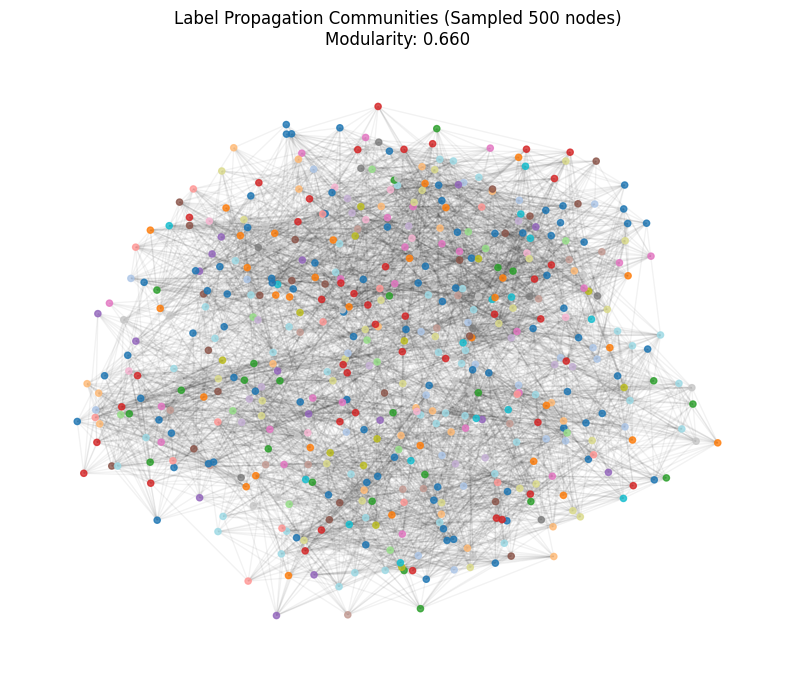

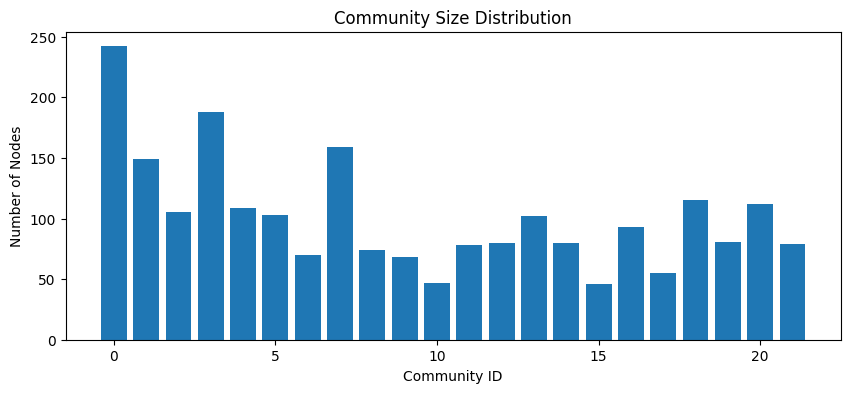

In [17]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from networkx.algorithms import community as nx_community
import pandas as pd

if 'G' not in locals():
    print("Creating mock graph for demonstration...")
    G = nx.erdos_renyi_graph(n=1000, p=0.02)  # Mock social network

# Preprocessing: Get largest connected component
largest_component = max(nx.connected_components(G), key=len)
G_cc = G.subgraph(largest_component).copy()

# Fast Community Detection (Label Propagation only)
print("Running Label Propagation...")
communities = list(nx_community.label_propagation_communities(G_cc))
partition = {node: i for i, comm in enumerate(communities) for node in comm}
modularity = nx_community.modularity(G_cc, communities)

print(f"\nCommunity Detection Results:")
print(f"- Method: Label Propagation")
print(f"- Modularity: {modularity:.4f}")
print(f"- Number of communities: {len(communities)}")

sample_size = 500
nodes = list(partition.keys())
if len(nodes) > sample_size:
    nodes = np.random.choice(nodes, size=sample_size, replace=False)

subgraph = G_cc.subgraph(nodes)
pos = nx.spring_layout(subgraph, k=0.3, iterations=20)

plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(
    subgraph, pos,
    node_size=20,
    node_color=[partition[n] for n in nodes],
    cmap=plt.cm.tab20,
    alpha=0.8
)
nx.draw_networkx_edges(subgraph, pos, alpha=0.05)
plt.title(f"Label Propagation Communities (Sampled {len(nodes)} nodes)\nModularity: {modularity:.3f}")
plt.axis('off')
plt.show()

# Community size distribution
comm_sizes = {i: len(comm) for i, comm in enumerate(communities)}
plt.figure(figsize=(10, 4))
plt.bar(comm_sizes.keys(), comm_sizes.values())
plt.title("Community Size Distribution")
plt.xlabel("Community ID")
plt.ylabel("Number of Nodes")
plt.show()